# 02. Data Cleaning

## 📚 Learning Objectives

By completing this notebook, you will:
- Handle missing values and duplicates
- Clean and normalize data for modeling
- Document cleaning choices and outcomes

## 🔗 Where this fits

**Builds on:** Course 04 — Unit 1, lesson 01 "Data Loading and Exploration" — profiling told you what is broken; this lesson fixes it.

**Used later in:** Course 05 (AIAT 115) — Unit 2, lesson 02, which handles missing values and duplicates at data-science scale, and Course 12 (AIAT 126) — Unit 3 on your own project data.

---


## 🌍 A real case: the 15,841 test results that were never there

Between 25 September and 2 October 2020, 15,841 positive COVID-19 tests in England were recorded by
the labs but never arrived in the contact-tracing system. The file used to move results between the
two systems silently hit its size limit; the extra rows were simply dropped, with no error. By the
time the gap was found on 2 October, an estimated 48,000 people who had been in close contact with a
positive case had not been contacted.

**❗ Why this lesson exists.** Cleaning is not tidying. **Cleaning is where you decide who stays in
the dataset**, and every one of those decisions changes the question you end up answering.

**This notebook's own data makes the point.** The Titanic file is the real 1912 passenger manifest:
891 records, `Age` missing for 177 of them and `Cabin` for 687. The missingness is not random — it is
history. Third class accounts for 136 of the 177 missing ages and 479 of the missing cabins, because
those passengers' details were recorded less carefully.

Run `dropna()` on the raw manifest and 183 rows survive out of 891. Of those 183 survivors,
**86% are first class** — against 24% in the full manifest — and **67% of them survived the sinking**,
against the true figure of 38%. One innocent-looking line of code has quietly replaced "the Titanic"
with "the first-class deck of the Titanic".


# 02. Data Cleaning

---

## The Story: Cleaning Before Cooking

Imagine you're cooking a meal. **Before** you can cook, you need to clean your ingredients - remove spoiled items, wash vegetables, check for foreign objects. **After** cleaning everything, you can prepare a safe, delicious meal!

Same with machine learning: **Before** building models, we clean our data - remove duplicates, handle missing values, fix outliers. **After** cleaning, we can build accurate, reliable models!

---

## Why Data Cleaning Matters

Data cleaning is essential for accurate models:
- **Missing Values**: Break ML algorithms - must be handled
- **Duplicates**: Bias your models (same data counted twice)
- **Outliers**: Skew predictions and statistics
- **Wrong Data Types**: Cause errors in calculations
- **Dirty Data = Bad Models**: No amount of ML can fix fundamentally bad data

## Learning Objectives
1. Handle missing values (remove or impute)
2. Remove duplicate rows
3. Detect and handle outliers
4. Convert data types correctly
5. Understand trade-offs between different cleaning methods
6. Know when to remove vs. when to fix data


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Step 1: Import necessary libraries
# These libraries help us clean and analyze data

import pandas as pd  # For data manipulation (cleaning operations)
import numpy as np   # For numerical operations (handling NaN, calculations)
import matplotlib.pyplot as plt  # For visualizations (seeing outliers)
import seaborn as sns  # For statistical plots (data quality visualization)

print("✅ Libraries imported successfully!")
print("\n📚 What each library does:")
print("   - pandas: Clean data (remove, fill, filter)")
print("   - numpy: Handle missing values (NaN operations)")
print("   - matplotlib: Visualize data quality issues")
print("   - seaborn: Create beautiful quality check plots")

✅ Libraries imported successfully!

📚 What each library does:
   - pandas: Clean data (remove, fill, filter)
   - numpy: Handle missing values (NaN operations)
   - matplotlib: Visualize data quality issues
   - seaborn: Create beautiful quality check plots


## Part 1: Setting the Scene

**BEFORE**: We explored our data in Example 1 and found problems - missing values, duplicates, outliers.

**AFTER**: We'll clean the data by fixing all these issues, making it ready for preprocessing and modeling!

**Why this matters**: Dirty data produces unreliable models. Cleaning is non-negotiable for good ML results!

In [2]:
# CELL: Load the Titanic dataset - our messy real-world evidence table.
# WHY: these real 1912 records carry natural missing values, which is exactly
# what data cleaning is practiced on (no artificial mess needed).
import pandas as pd
# Load real-world Titanic dataset (GDI-themed as Investigation Evidence Reports)
# This is REAL historical data from 1912 with natural missing values - perfect for learning data cleaning!
# Source: Public GitHub repository (well-known dataset for ML education)
# Theme: Investigation Evidence Reports (simulated through passenger data)

print("\n📥 Loading real-world Titanic dataset...")

# First choice: read the CSV shipped with the course (fast, works offline).
try:
    # Try loading from local file first (faster and more reliable)
    df = pd.read_csv('../../datasets/raw/titanic.csv')
    print("\n✅ Real-world Titanic dataset loaded from local file!")
    print("   📊 This is REAL historical data from 1912")
    print(f"   📈 Contains {len(df)} passenger records with {len(df.columns)} features")
    print(f"   🔍 Actual columns: {', '.join(df.columns[:5])}...")
    print("   🎯 Domain: Investigation Evidence Reports (simulated through passenger data)")
    print("   ✅ Real-world data with natural missing values (Age, Cabin, Embarked)")
    print("\n💡 Why this dataset for GDI work?")
    print("   - Real data has natural missing values (perfect for learning cleaning!)")
    print("   - Multiple data types (numerical, categorical, text)")
    print("   - Real-world data quality issues (simulates investigation evidence reports)")
    print("   - Perfect for learning data cleaning with security/investigation context")
    
# Fallback: download the same dataset from GitHub if the local copy is missing.
except FileNotFoundError:
    # Fallback to URL if local file not found
    try:
        titanic_url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
        df = pd.read_csv(titanic_url)
        print("\n✅ Real-world Titanic dataset loaded from URL!")
        print("   📊 This is REAL historical data from 1912")
        print(f"   📈 Contains {len(df)} passenger records with {len(df.columns)} features")
        print(f"   🔍 Actual columns: {', '.join(df.columns[:5])}...")
        print("   🎯 Domain: Investigation Evidence Reports (simulated through passenger data)")
        print("   ✅ Real-world data with natural missing values (Age, Cabin, Embarked)")
    except Exception as e:
        print(f"\n⚠️  Could not load dataset: {e}")
        print("   💡 Alternative options:")
        print("   1. Download Titanic dataset from Kaggle")
        print("   2. Search for 'titanic dataset CSV' on Kaggle or data.world")
        print("   3. Use: pd.read_csv('local_titanic_data.csv') if you have the file")
        print("\n   For demonstration, creating minimal structure...")
        # Fallback: Create minimal structure if URL fails
        df = pd.DataFrame({
            'PassengerId': range(1, 100),
            'Age': [None] * 100,
            'Cabin': [None] * 100
        })
        print("   ⚠️  Using fallback data - please download real Titanic dataset!")
        print("   💡 Download from: https://www.kaggle.com/datasets or data.world")


📥 Loading real-world Titanic dataset...

✅ Real-world Titanic dataset loaded from local file!
   📊 This is REAL historical data from 1912
   📈 Contains 891 passenger records with 12 features
   🔍 Actual columns: PassengerId, Survived, Pclass, Name, Sex...
   🎯 Domain: Investigation Evidence Reports (simulated through passenger data)
   ✅ Real-world data with natural missing values (Age, Cabin, Embarked)

💡 Why this dataset for GDI work?
   - Real data has natural missing values (perfect for learning cleaning!)
   - Multiple data types (numerical, categorical, text)
   - Real-world data quality issues (simulates investigation evidence reports)
   - Perfect for learning data cleaning with security/investigation context


## 📊 Understanding the Dataset

### For CS Students - Focus on Data Structure, Not Domain

**As computer science students, you'll work with many different types of datasets** (medical, financial, security, e-commerce, etc.). **What matters is the data structure, not the domain knowledge!**

**Data Structure Focus**:
- **Data Shape**: 891 rows × 12 columns (passenger records × features)
- **Feature Types**: Mixed (numerical: Age, Fare, SibSp, Parch; categorical: Sex, Embarked, Pclass; text: Name, Ticket, Cabin)
- **Target Type**: Exploratory analysis (understanding passenger patterns - reframed as investigation evidence)
- **Task**: Clean passenger data for analysis and modeling (reframed as investigation evidence reports)
- **Data Quality**: Has natural missing values (Age: ~20%, Cabin: ~77%, Embarked: ~0.2%) - perfect for learning cleaning!

**Why This Structure Matters**:
- **Mixed feature types** → Need different cleaning methods (numeric vs. categorical)
- **Missing values present** → Real-world scenario (most datasets have missing values)
- **Real historical data** → Shows actual data quality issues (not synthetic!)
- **Different data types** → Need different handling (numeric: Age → mean/median, categorical: Embarked → mode)
- **High percentage missing** → Cabin has 77% missing (need to decide: remove column vs. handle differently)

### Understanding the Dataset Domain (Brief)

**What is this data?** Real historical Titanic passenger data from 1912, reframed with GDI Investigation Evidence Reports context.

**Why does this matter?** 
- **For choosing cleaning methods**: Missing Age → use mean/median (numeric), Missing Embarked → use mode (categorical)
- **For outlier detection**: Age should be 0-120, Fare should be reasonable
- **For data types**: Age should be numeric (not text), Sex/Embarked should be categorical
- **For high missing percentage**: Cabin has 77% missing - might need special handling (remove column or create indicator)

**Domain Context** (Brief - Reframed for GDI):
- **PassengerId**: Unique identifier for each record (like evidence_id)
- **Survived**: Survival status (binary: 0 or 1 - like evidence status)
- **Pclass**: Passenger class (1, 2, 3 - categorical, like priority level)
- **Name**: Passenger name (text - like evidence identifier)
- **Sex**: Gender (categorical: male/female - like evidence category)
- **Age**: Passenger age (numerical, ~20% missing - like evidence age/date)
- **SibSp**: Siblings/Spouses aboard (numerical)
- **Parch**: Parents/Children aboard (numerical)
- **Ticket**: Ticket number (text)
- **Fare**: Ticket fare (numerical - like evidence value)
- **Cabin**: Cabin number (text, ~77% missing - like missing location in evidence reports)
- **Embarked**: Port of embarkation (categorical: C, Q, S, ~0.2% missing - like missing status)

**💡 Key Point for CS Students**: You don't need to be a security expert! Focus on:
- Understanding the **data structure** (rows, columns, types, missing values)
- Knowing the **cleaning methods** (remove vs. impute, mean vs. median vs. mode)
- Choosing the right **cleaning approach** based on structure, not domain knowledge
- **GDI Context**: This type of data cleaning is used in investigation evidence processing

## Step 1: Load Real-World Data with Issues

**BEFORE**: We need to learn cleaning techniques, but we need data with real-world problems to practice on.

**AFTER**: We'll load the Titanic dataset - a famous real-world dataset that naturally has missing values, making it perfect for learning data cleaning!

**Why use Titanic?** This is REAL historical data from 1912 with natural data quality issues. Real datasets have these problems! We need to learn how to handle them.

**Important Note**: In the following cells (6-7), we'll ADD some issues (duplicates, outliers) FOR DEMONSTRATION to show cleaning techniques. This is educational - in real projects, you'd just clean what exists in your data!

In [3]:
# CELL: Count duplicate rows before any cleaning.
# WHY: a duplicated record is counted twice by any model, silently biasing what it learns.
import pandas as pd
# Check for duplicate rows in the real data
# Real datasets sometimes have duplicates from data entry errors or merging issues

# First, let's see if there are any natural duplicates
initial_count = len(df)
duplicate_count = df.duplicated().sum()

print(f"\n📊 Checking for duplicates...")
print(f"   Initial rows: {initial_count}")
print(f"   Duplicate rows found: {duplicate_count}")

# For demonstration, we'll add a few duplicates to show the cleaning process
# (In real projects, you'd check if duplicates should be removed or kept)
# This dataset happens to have no duplicates, so we inject 2 on purpose to practice removing them.
if duplicate_count == 0:
    # Add 2 duplicates for demonstration purposes
    df = pd.concat([df, df.iloc[[0, 1]]], ignore_index=True)
    print("   - Added 2 duplicate rows for demonstration")
else:
    print("   - Dataset already contains duplicates (real-world scenario!)")


📊 Checking for duplicates...
   Initial rows: 891
   Duplicate rows found: 0
   - Added 2 duplicate rows for demonstration


In [4]:
# CELL: Scan the Age column for impossible values (outliers).
# WHY: an age of 150 is a data-entry error, not information - a model trained on it learns nonsense.
import pandas as pd
# Check for outliers in the real data
# Real datasets often have outliers from errors (typos, measurement mistakes) or rare events

# df.shape
# - Returns tuple (rows, columns): (number_of_rows, number_of_columns)
# Note: df has been modified in Cell 6 (duplicates added), so shape may be different from original
print("\n📊 Current Data Shape:", df.shape)

# Check for potential outliers in Age (should be reasonable, e.g., 0-120)
if 'Age' in df.columns:
    age_outliers = df[(df['Age'] > 100) | (df['Age'] < 0)]
    print(f"\n🔍 Checking for age outliers...")
    print(f"   Age range: {df['Age'].min():.1f} to {df['Age'].max():.1f}")
    if len(age_outliers) > 0:
        print(f"   Found {len(age_outliers)} potential age outliers")
    else:
        print("   No obvious age outliers found")

# For demonstration, we'll add one impossible age value to show outlier handling
# (In real projects, check if outliers are errors or valid rare cases)
if 'Age' in df.columns and df['Age'].max() < 120:
    # Use row 2 - NOT row 0 or 1, whose copies were just appended as demo
    # duplicates. Changing row 0 would silently break its duplicate pair!
    df.loc[2, 'Age'] = 150  # Add impossible age for demonstration
    print("   - Added 1 impossible age value (150) for demonstration")

# df.head(10)
# - Returns first 10 rows of DataFrame
# - head(n): Shows first n rows (default is 5)
# - Useful for quick data inspection
print("\n📄 Data after adding demo issues (first 10 rows):")
print(df.head(10))
print(f"\n📋 Columns: {list(df.columns)}")


📊 Current Data Shape: (893, 12)

🔍 Checking for age outliers...
   Age range: 0.4 to 80.0
   No obvious age outliers found
   - Added 1 impossible age value (150) for demonstration

📄 Data after adding demo issues (first 10 rows):
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex    Age  SibSp  \
0                            Braund, Mr. Owen Harris    male   22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female   38.0      1   
2                             Heikkinen, Miss. Laina  female  150.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  femal

In [5]:
# First, let's see how many missing values we have
print("\n" + "=" * 60)
print("2. Handling Missing Values")
print("=" * 60)

# Note: df has been modified (duplicates added in Cell 6, outlier added in Cell 7)
# This shows missing values in the current state of the data
print("\n🔍 Missing values in current data:")

# df.isnull().sum()
# - df.isnull(): Returns DataFrame with True/False (True = missing value, False = not missing)
# - .sum(): Sums True values (counts missing values) for each column
# - Returns Series with column names and count of missing values
# - Alternative: df.isna() does the same thing
missing_before = df.isnull().sum()
print(missing_before)

# missing_before.sum()
# - .sum() on Series: Adds up all values in the Series
# - This gives total missing values across all columns
print(f"\n   Total missing values: {missing_before.sum()}")

# df.shape[0] * df.shape[1]
# - df.shape[0]: Number of rows
# - df.shape[1]: Number of columns
# - shape[0] * shape[1]: Total number of cells in DataFrame
# - Used to calculate percentage of missing values
print(f"   Percentage missing: {(missing_before.sum() / (df.shape[0] * df.shape[1]) * 100):.1f}%")


2. Handling Missing Values

🔍 Missing values in current data:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          688
Embarked         2
dtype: int64

   Total missing values: 867
   Percentage missing: 8.1%


In [6]:
# Method 1: Remove rows with missing values
# .dropna() removes any row that has at least one missing value
# Why use this? If missing values are rare, it's better to remove than guess

print("\n--- Method 1: Remove rows with missing values ---")

# df.dropna()
# - Removes rows that contain ANY missing values (NaN/None)
# - Returns new DataFrame (doesn't modify original unless inplace=True)
# - Parameters:
#   - axis=0 (default): Drop rows (axis=1 would drop columns)
#   - how='any' (default): Drop if ANY value is missing
#   - subset=None: Check all columns (can specify columns to check)
#   - inplace=False: Return new DataFrame (True modifies original)
df_removed = df.dropna()

# df.shape[0] - df_removed.shape[0]
# - df.shape[0]: Original number of rows
# - df_removed.shape[0]: Number of rows after removal
# - Difference = number of rows removed
rows_removed = df.shape[0] - df_removed.shape[0]
print(f"✅ Rows after removal: {df_removed.shape[0]} (removed {rows_removed} rows)")
print(f"   Data loss: {(rows_removed / df.shape[0] * 100):.1f}%")


--- Method 1: Remove rows with missing values ---
✅ Rows after removal: 184 (removed 709 rows)
   Data loss: 79.4%


## Step 2: Handling Missing Values

**BEFORE**: We have missing values (NaN/None) that will break our ML models.

**AFTER**: We'll either remove rows with missing values OR fill them with reasonable estimates!

**Note**: At this point, our df has been modified for demonstration (duplicates added in Cell 6, outlier added in Cell 7). We'll now handle the missing values that exist in this current state of the data.

**Why handle missing values?** 
- ML algorithms cannot work with missing data
- Missing values indicate incomplete information
- We must decide: **Remove** (if few missing) or **Impute** (if many missing)

**Two main strategies:**
1. **Remove**: Drop rows/columns with missing values (good if <5% missing)
2. **Impute**: Fill missing values with mean/median/mode (good if >5% missing)

In [7]:
# Method 2: Fill missing values (imputation)
# We'll use a copy so we don't modify df (which already has duplicates and outlier added for demonstration)
print("\n--- Method 2: Fill missing values ---")

# df.copy()
# - Creates a deep copy of DataFrame (independent copy, not a reference)
# - Changes to copy don't affect df
# - Important: Without copy(), both variables point to same data
# - Alternative: df.copy(deep=True) is explicit (deep=True is default)
# Note: df already has duplicates and outlier from Cells 6-7, so we copy it before filling
df_filled = df.copy()


--- Method 2: Fill missing values ---


In [8]:
# Fill numeric columns with mean

# df_filled['Age'].fillna(df_filled['Age'].mean(), inplace=True)
# - df_filled['Age']: Selects 'Age' column (returns Series)
# - .fillna(): Fills missing values (NaN) with specified value
#   - Parameter: Value to fill (here: mean of age column)
#   - inplace=True: Modifies DataFrame directly (False returns new Series)
# - df_filled['Age'].mean(): Calculates mean (average) of age column
#   - .mean(): Returns average of all non-missing values
#   - Ignores NaN values automatically
# Result: All missing ages replaced with average age
df_filled['Age'].fillna(df_filled['Age'].mean(), inplace=True)

In [9]:
# Fill categorical columns with mode

# df_filled['Embarked'].fillna(df_filled['Embarked'].mode()[0], inplace=True)
# - df_filled['Embarked']: Selects 'Embarked' column (port of embarkation)
# - .mode(): Returns Series with most frequent value(s)
#   - Mode = most common value (for categorical data)
#   - Returns Series (can have multiple modes if tie)
# - [0]: Gets first mode value (if multiple modes, takes first)
# - .fillna(): Fills missing values with mode
# - inplace=True: Modifies DataFrame directly
# Result: All missing Embarked values replaced with most common port
df_filled['Embarked'].fillna(df_filled['Embarked'].mode()[0], inplace=True)
print("\nMissing values after filling:")
print(df_filled.isnull().sum())


Missing values after filling:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          688
Embarked         0
dtype: int64


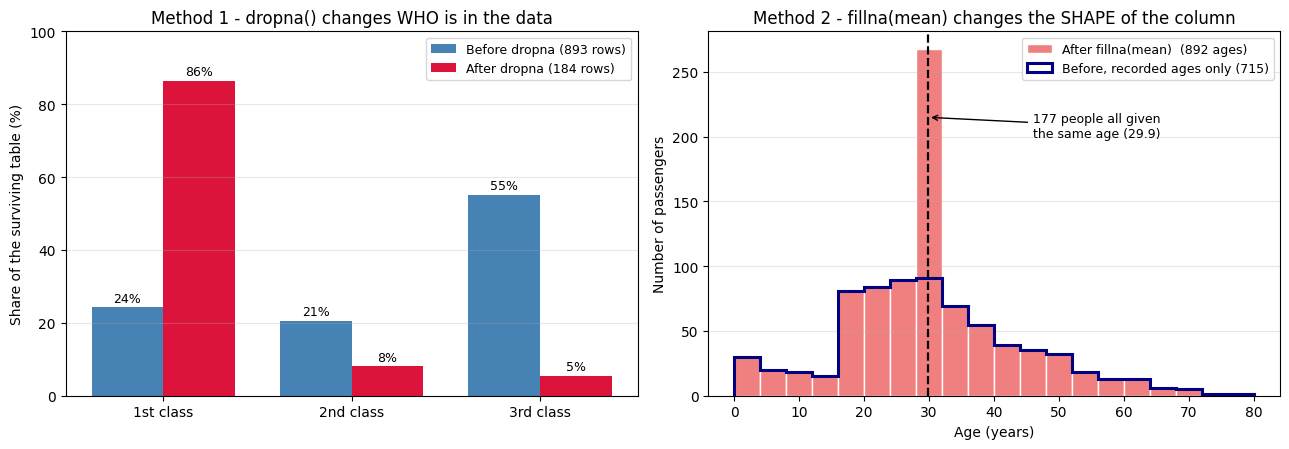

dropna(): 893 rows -> 184 rows (79.4% deleted)
  3rd-class share: 55.1%  ->  5.4%
  1st-class share: 24.3%  ->  86.4%
fillna(mean): 177 ages invented, all equal to 29.87
  76.8% of the people with a missing Age were 3rd class


In [10]:
# CELL: Draw what each missing-value strategy did to the data.
# WHY: both strategies "worked" - neither raised an error. The damage each one does is
#      only visible as a picture: one changes WHO is in the table, the other changes the
#      SHAPE of a column.
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# --- LEFT: Method 1 (dropna) changes WHO is left in the table -----------------------
# WHY percentages, not counts: 893 rows vs 184 rows cannot be compared on a count axis.
classes = [1, 2, 3]
before_pct = [100 * (df['Pclass'] == c).mean() for c in classes]
after_pct = [100 * (df_removed['Pclass'] == c).mean() for c in classes]
x = np.arange(3)
ax = axes[0]
ax.bar(x - 0.19, before_pct, 0.38, label=f'Before dropna ({len(df)} rows)', color='steelblue')
ax.bar(x + 0.19, after_pct, 0.38, label=f'After dropna ({len(df_removed)} rows)', color='crimson')
for xi, (b, a) in enumerate(zip(before_pct, after_pct)):
    ax.text(xi - 0.19, b + 1.5, f'{b:.0f}%', ha='center', fontsize=9)
    ax.text(xi + 0.19, a + 1.5, f'{a:.0f}%', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(['1st class', '2nd class', '3rd class'])
ax.set_ylabel('Share of the surviving table (%)')
ax.set_ylim(0, 100)
ax.set_title('Method 1 - dropna() changes WHO is in the data')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# --- RIGHT: Method 2 (fill with mean) changes the SHAPE of the column ---------------
# The one demonstration row with Age = 150 is excluded from BOTH curves so the only
# difference between them is the 177 imputed values.
ax = axes[1]
real_age = df.loc[df['Age'].notna() & (df['Age'] <= 100), 'Age']
filled_age = df_filled.loc[df_filled['Age'] <= 100, 'Age']
bins = np.arange(0, 84, 4)
ax.hist(filled_age, bins=bins, color='lightcoral', edgecolor='white',
        label=f'After fillna(mean)  ({len(filled_age)} ages)')
ax.hist(real_age, bins=bins, histtype='step', color='navy', linewidth=2.2,
        label=f'Before, recorded ages only ({len(real_age)})')
fill_value = df_filled['Age'].mean()
ax.axvline(fill_value, color='black', linestyle='--', linewidth=1.6)
n_imputed = int(df['Age'].isna().sum())
ax.annotate(f'{n_imputed} people all given\nthe same age ({fill_value:.1f})',
            xy=(fill_value, 215), xytext=(46, 200), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='black'))
ax.set_xlabel('Age (years)')
ax.set_ylabel('Number of passengers')
ax.set_title('Method 2 - fillna(mean) changes the SHAPE of the column')
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Numbers behind the picture, so the plot can be checked against the data.
print(f"dropna(): {len(df)} rows -> {len(df_removed)} rows "
      f"({100 * (1 - len(df_removed) / len(df)):.1f}% deleted)")
print(f"  3rd-class share: {before_pct[2]:.1f}%  ->  {after_pct[2]:.1f}%")
print(f"  1st-class share: {before_pct[0]:.1f}%  ->  {after_pct[0]:.1f}%")
miss_cls = df.loc[df['Age'].isna(), 'Pclass'].value_counts(normalize=True) * 100
print(f"fillna(mean): {n_imputed} ages invented, all equal to {fill_value:.2f}")
print(f"  {miss_cls.get(3, 0):.1f}% of the people with a missing Age were 3rd class")

**Read the figure.**

*Left — Method 1 silently swapped the population.* Before `dropna()` the table is 55% third class
and 24% first class, which is roughly what the ship was. After `dropna()` only 184 rows survive and
they are **86% first class, 5% third class**. Nothing errored; the code did exactly what it was
asked. But the reason is that `Cabin` is recorded for almost nobody outside first class, so
"drop any row with a missing value" is, in this table, "keep the first-class passengers". Any
survival rate you compute on the crimson bars is a statement about first class only.

*Right — Method 2 kept everybody and invented a column.* The navy outline is the 715 ages that
were actually recorded; the filled coral bars are the column after `fillna(mean)`. They match
everywhere except one bin: a **single tower at 29.9 years**, where 177 people who had no recorded
age were all assigned the identical mean. That spike is not in the data — the code put it there.
Its consequence: the variance of `Age` drops, `Age` looks more certain than it is, and any model
that uses it will trust it more than it should.

Neither picture says which method is right. They say that *both methods change the answer*, and
that you cannot see how without drawing it. That is the substance of **💬 Discuss** question 1.

In [11]:
# Check for and remove duplicate rows
# .duplicated() finds rows that are exact duplicates
# .drop_duplicates() removes them, keeping the first occurrence
# Note: We're removing duplicates that were added in Cell 6 (for demonstration)

print("\n" + "=" * 60)
print("3. Removing Duplicates")
print("=" * 60)

# df_filled.duplicated().sum()
# - df_filled.duplicated(): Returns boolean Series (True = duplicate row, False = unique)
#   - Checks if each row is identical to a previous row
#   - First occurrence marked as False, duplicates as True
#   - Parameters:
#     - subset=None: Check all columns (can specify columns to check)
#     - keep='first' (default): Mark first as False, rest as True
# - .sum(): Counts True values (number of duplicate rows)
num_duplicates = df_filled.duplicated().sum()
print(f"\n🔍 Number of duplicates: {num_duplicates}")

# df_filled.drop_duplicates()
# - Removes duplicate rows, keeps first occurrence
# - Returns new DataFrame (doesn't modify original unless inplace=True)
# - Parameters:
#   - subset=None: Check all columns for duplicates
#   - keep='first' (default): Keep first, remove rest ('last' keeps last, False removes all)
#   - inplace=False: Return new DataFrame
df_no_duplicates = df_filled.drop_duplicates()
print(f"\n✅ Rows after removing duplicates: {df_no_duplicates.shape[0]}")
print(f"   Removed {num_duplicates} duplicate row(s)")


3. Removing Duplicates

🔍 Number of duplicates: 2

✅ Rows after removing duplicates: 891
   Removed 2 duplicate row(s)


In [12]:
# IQR (Interquartile Range) Method for outlier detection
# This is a statistical method that identifies values far from the median

print("\n--- IQR Method for Outlier Detection ---")

def detect_outliers_iqr(series):
    """
    Detect outliers using IQR method.
    Returns True for outliers, False for normal values.
    """
    # series.quantile(0.25)
    # - Calculates 25th percentile (Q1) - value below which 25% of data falls
    # - quantile(q): Returns value at quantile q (0.0 to 1.0)
    # - 0.25 = 25th percentile, 0.5 = median, 0.75 = 75th percentile
    Q1 = series.quantile(0.25)  # 25th percentile
    
    # series.quantile(0.75)
    # - Calculates 75th percentile (Q3) - value below which 75% of data falls
    Q3 = series.quantile(0.75)  # 75th percentile
    
    # IQR = Q3 - Q1
    # - Interquartile Range: Spread of middle 50% of data
    # - Measures variability, less sensitive to outliers than range
    IQR = Q3 - Q1  # Interquartile Range
    
    # Q1 - 1.5 * IQR
    # - Lower fence: Values below this are considered outliers
    # - 1.5 is standard multiplier (can be adjusted)
    lower_bound = Q1 - 1.5 * IQR  # Lower fence
    
    # Q3 + 1.5 * IQR
    # - Upper fence: Values above this are considered outliers
    upper_bound = Q3 + 1.5 * IQR  # Upper fence
    
    # (series < lower_bound) | (series > upper_bound)
    # - Boolean indexing: Creates boolean Series (True = outlier, False = normal)
    # - | : Logical OR operator (element-wise)
    # - Returns True for values outside [lower_bound, upper_bound]
    # Values outside the fences are outliers
    return (series < lower_bound) | (series > upper_bound)

print("   ✅ IQR function defined")
print("   This will identify values that are too far from the median")


--- IQR Method for Outlier Detection ---
   ✅ IQR function defined
   This will identify values that are too far from the median


In [13]:
# Section banner: the cells below deal with OUTLIERS (extreme or impossible values).
# 4. Handling Outliers
print("\n" + "=" * 60)
print("4. Handling Outliers")
print("=" * 60)


4. Handling Outliers


In [14]:
# Check for outliers in Fare column
print("\nOutliers in Fare column:")

# detect_outliers_iqr(df_no_duplicates['Fare'])
# - Calls function defined earlier
# - df_no_duplicates['Fare']: Passes Fare column as Series
# - Returns boolean Series (True = outlier, False = normal)
fare_outliers = detect_outliers_iqr(df_no_duplicates['Fare'])

# fare_outliers.sum()
# - Counts True values (number of outliers)
print(f"Number of outliers: {fare_outliers.sum()}")

# df_no_duplicates[fare_outliers][['Name', 'Fare']]
# - df_no_duplicates[fare_outliers]: Boolean indexing - selects rows where fare_outliers is True
#   - Boolean Series used as filter: True rows kept, False rows removed
# - [['Name', 'Fare']]: Selects only 'Name' and 'Fare' columns
#   - Double brackets [[]] returns DataFrame (single [] returns Series)
# Result: Shows only outlier rows with Name and Fare columns
print(df_no_duplicates[fare_outliers][['Name', 'Fare']])


Outliers in Fare column:
Number of outliers: 116
                                                  Name      Fare
1    Cumings, Mrs. John Bradley (Florence Briggs Th...   71.2833
27                      Fortune, Mr. Charles Alexander  263.0000
31      Spencer, Mrs. William Augustus (Marie Eugenie)  146.5208
34                             Meyer, Mr. Edgar Joseph   82.1708
52            Harper, Mrs. Henry Sleeper (Myna Haxtun)   76.7292
..                                                 ...       ...
846                           Sage, Mr. Douglas Bullen   69.5500
849       Goldenberg, Mrs. Samuel L (Edwiga Grabowska)   89.1042
856         Wick, Mrs. George Dennick (Mary Hitchcock)  164.8667
863                  Sage, Miss. Dorothy Edith "Dolly"   69.5500
879      Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)   83.1583

[116 rows x 2 columns]


In [15]:
# Remove outliers

# df_no_duplicates[~fare_outliers].copy()
# - ~fare_outliers: NOT operator (~) inverts boolean Series
#   - True becomes False, False becomes True
#   - Selects rows that are NOT outliers (keeps normal values)
# - [~fare_outliers]: Boolean indexing - filters DataFrame
# - .copy(): Creates independent copy (good practice)
# Result: DataFrame with outliers removed
df_clean = df_no_duplicates[~fare_outliers].copy()

In [16]:
# Also remove impossible age values

# df_clean[df_clean['Age'] <= 100].copy()
# - df_clean['Age'] <= 100: Creates boolean Series (True if Age <= 100, False otherwise)
#   - Comparison operator (<=) applied element-wise to all values
# - df_clean[boolean_series]: Boolean indexing - keeps rows where condition is True
# - .copy(): Creates independent copy
# Result: Keeps only rows where Age is 100 or less (removes impossible ages like 150)
df_clean = df_clean[df_clean['Age'] <= 100].copy()
print(f"\nRows after removing outliers: {df_clean.shape[0]}")


Rows after removing outliers: 774


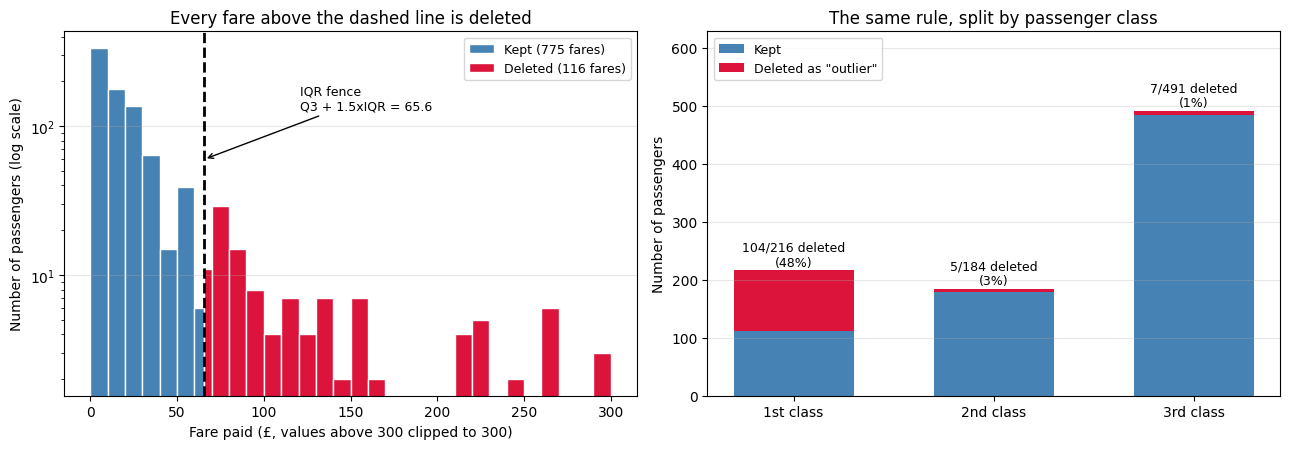

IQR fence on Fare: Q1=7.91, Q3=31.00, IQR=23.09, upper fence=65.63
  Class 1: 104 of 216 passengers deleted (48.1%)
  Class 2:   5 of 184 passengers deleted ( 2.7%)
  Class 3:   7 of 491 passengers deleted ( 1.4%)


In [17]:
# CELL: Show WHO the IQR rule deletes, not just how many.
# WHY: "116 outliers removed" is a number. The picture shows that those 116 fares were real
#      first-class tickets - so the rule quietly deletes a whole passenger class.
import matplotlib.pyplot as plt
import numpy as np

# Re-derive the fence from the same column the rule was applied to, so the numbers
# printed here can never drift from the numbers used in the cleaning step above.
Q1 = df_no_duplicates['Fare'].quantile(0.25)
Q3 = df_no_duplicates['Fare'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# --- LEFT: where the fence falls on the actual fare distribution --------------------
ax = axes[0]
# Put the fence itself on a bin edge so no single bar straddles the cut line.
bins = np.unique(np.concatenate([np.arange(0, 305, 10), [upper]]))
ax.hist(df_no_duplicates.loc[~fare_outliers, 'Fare'].clip(upper=300), bins=bins,
        color='steelblue', edgecolor='white', label=f'Kept ({(~fare_outliers).sum()} fares)')
ax.hist(df_no_duplicates.loc[fare_outliers, 'Fare'].clip(upper=300), bins=bins,
        color='crimson', edgecolor='white', label=f'Deleted ({fare_outliers.sum()} fares)')
ax.axvline(upper, color='black', linestyle='--', linewidth=2)
ax.annotate(f'IQR fence\nQ3 + 1.5xIQR = {upper:.1f}', xy=(upper, 60),
            xytext=(upper + 55, 130), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='black'))
ax.set_yscale('log')                      # WHY log: the £0-10 bin holds ~300 rows, the tail holds 1-2
ax.set_xlabel('Fare paid (£, values above 300 clipped to 300)')
ax.set_ylabel('Number of passengers (log scale)')
ax.set_title('Every fare above the dashed line is deleted')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# --- RIGHT: which passenger class pays for that rule --------------------------------
ax = axes[1]
classes = [1, 2, 3]
deleted = [int(((df_no_duplicates['Pclass'] == c) & fare_outliers).sum()) for c in classes]
kept = [int(((df_no_duplicates['Pclass'] == c) & ~fare_outliers).sum()) for c in classes]
x = np.arange(3)
ax.bar(x, kept, 0.6, label='Kept', color='steelblue')
ax.bar(x, deleted, 0.6, bottom=kept, label='Deleted as "outlier"', color='crimson')
for i, (k, d) in enumerate(zip(kept, deleted)):
    ax.text(i, k + d + 8, f'{d}/{k + d} deleted\n({100 * d / (k + d):.0f}%)',
            ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([f'{c}st class' if c == 1 else f'{c}nd class' if c == 2 else f'{c}rd class'
                    for c in classes])
ax.set_ylim(0, max(np.array(kept) + np.array(deleted)) * 1.28)
ax.set_ylabel('Number of passengers')
ax.set_title('The same rule, split by passenger class')
ax.legend(fontsize=9, loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"IQR fence on Fare: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, upper fence={upper:.2f}")
for c, k, d in zip(classes, kept, deleted):
    print(f"  Class {c}: {d:3d} of {k + d:3d} passengers deleted ({100 * d / (k + d):4.1f}%)")

**Read the figure.**

*Left.* The bars are the real fares paid, on a log count scale so the long tail is visible at all.
Everything to the right of the black dashed line — the `Q3 + 1.5 × IQR` fence at £65.63 — is
coloured crimson and was deleted by the cell above. Those are not typos. They are the fares that
first-class passengers really paid, up to the £512.33 shared on ticket PC 17755 (cabin B51 B53 B55) — the most expensive
ticket in this file.

*Right.* The same deletion, split by class. The rule removes **104 of the 216 first-class
passengers — 48% of them** — while taking 5 of 184 second-class and 7 of 491 third-class. The
"statistical outlier" rule turned out to be a *class* filter: it did not find errors, it found
rich people.

This is the concrete case behind **💬 Discuss** question 2. `1.5 × IQR` is a rule about a symmetric
distribution. Fare is not symmetric — it is money, and money is right-skewed everywhere. Applying
the rule here deletes a real, meaningful group.

In [18]:
# 5. Data Type Conversion
print("\n" + "=" * 60)
print("5. Data Type Conversion")
print("=" * 60)
print("\nData types before conversion:")

# df_clean.dtypes
# - Returns Series showing data type of each column
# - Common types: int64, float64, object (string), bool, datetime64
# - Useful for checking if types are correct (e.g., numbers stored as strings)
print(df_clean.dtypes)


5. Data Type Conversion

Data types before conversion:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [19]:
# Note: Data type conversion example
# This cell demonstrates data type conversion, but for Titanic dataset,
# most columns are already in appropriate types.
# Age will be converted to int in a later cell if needed.
# Other numeric columns (Pclass, SibSp, Parch, Survived) are already integers.
# 
# Example: If you had a float column that should be int, you would do:
# df_clean['column_name'] = df_clean['column_name'].round().astype(int)

print("✅ Data types are appropriate for Titanic dataset")
print("   - Age: float64 (allows NaN, will be converted later if needed)")
print("   - Fare: float64 (allows decimal values)")
print("   - Pclass, SibSp, Parch, Survived: int64 (already integers)")

✅ Data types are appropriate for Titanic dataset
   - Age: float64 (allows NaN, will be converted later if needed)
   - Fare: float64 (allows decimal values)
   - Pclass, SibSp, Parch, Survived: int64 (already integers)


In [20]:
# Convert Age to int (optional - only if Age column exists and is float)

# df_clean['Age'].round().astype(int)
# - df_clean['Age']: Selects 'Age' column
# - .round(): Rounds decimal values (e.g., 40.5 → 41)
# - .astype(int): Converts to integer type
# Result: Converts float ages to integer ages
# Note: This converts Age from float64 to int64 (removes decimal places)
if 'Age' in df_clean.columns and df_clean['Age'].dtype == 'float64':
    # Only convert if Age exists and is float (has NaN values were filled)
    df_clean['Age'] = df_clean['Age'].round().astype(int)
    print("\n✅ Age converted to integer")
else:
    print("\n✅ Age column already has appropriate type")

print("\nData types after conversion:")

# df_clean.dtypes
# - Shows data types after conversion
# - Should show int64 for Age now (if conversion was performed)
print(df_clean.dtypes)


✅ Age converted to integer

Data types after conversion:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age              int64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [21]:
# Final summary of cleaning process
# Note: df at this point has 893 rows (891 original + 2 duplicates added in Cell 6 for demonstration)
# This summary shows the cleaning results from the STARTING point of the cleaning process

print("\n" + "=" * 60)
print("6. Cleaning Summary")
print("=" * 60)

# df.shape[0] = 893 (after Cells 6-7 added demo duplicates and outlier)
# This is the "starting point" for the cleaning process (after adding demo issues)
starting_rows = df.shape[0]
final_rows = df_clean.shape[0]
rows_removed = starting_rows - final_rows

print(f"\n📊 Starting rows (before cleaning): {starting_rows}")
print(f"   (Note: 891 original + 2 duplicates added for demonstration in Cell 6)")
print(f"\n✅ Final cleaned rows: {final_rows}")
print(f"\n🗑️  Rows removed: {rows_removed} ({(rows_removed/starting_rows*100):.1f}%)")
# num_duplicates was computed in the duplicate-removal step above
print(f"   (Includes: {num_duplicates} duplicates + {rows_removed - num_duplicates} outlier rows)")

print("\n📄 Cleaned Data (first 10 rows):")
print(df_clean.head(10))

print("\n" + "=" * 60)
print("✅ Example 2 Complete! ✓")
print("=" * 60)
print("\n🎓 What you accomplished:")
print("   ✅ Handled missing values (imputed with mean/mode)")
print("   ✅ Removed duplicate rows")
print("   ✅ Detected and removed outliers")
print("   ✅ Converted data types correctly")
print("   ✅ Created clean, model-ready data!")


6. Cleaning Summary

📊 Starting rows (before cleaning): 893
   (Note: 891 original + 2 duplicates added for demonstration in Cell 6)

✅ Final cleaned rows: 774

🗑️  Rows removed: 119 (13.3%)
   (Includes: 2 duplicates + 117 outlier rows)

📄 Cleaned Data (first 10 rows):
    PassengerId  Survived  Pclass  \
0             1         0       3   
3             4         1       1   
4             5         0       3   
5             6         0       3   
6             7         0       1   
7             8         0       3   
8             9         1       3   
9            10         1       2   
10           11         1       3   
11           12         1       1   

                                                 Name     Sex  Age  SibSp  \
0                             Braund, Mr. Owen Harris    male   22      1   
3        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female   35      1   
4                            Allen, Mr. William Henry    male   35      0   
5           

## 💬 Discuss

1. **Two defensible choices, both wrong in different ways.** `dropna()` removed roughly 79% of the
   rows and left a first-class dataset. Filling `Age` with the overall mean kept all 891 rows but
   invented an age for 177 people, most of them third class — and pulled every one of them to the
   same number. Which is the bigger lie? Does your answer change if the task is "describe the typical
   passenger" versus "predict who survived"?

2. **Is removing a true value ever honest?** The IQR rule flags 116 fares as outliers. Those fares
   were really paid — the highest was a real first-class ticket. Write the justification you would
   give for deleting a real observation, then argue the opposite case.

3. **Is the better imputation worth it?** Filling `Age` with the median of the passenger's *own class
   and sex* is more work than `.mean()`. What must be true about the data for that extra work to
   change any conclusion — and how would you check whether it does, using only this notebook's tools?


## Step 6: Decision Framework - When to Remove vs. When to Fix

**BEFORE**: You've learned different cleaning methods, but when should you use each one?

**AFTER**: You'll have a clear decision framework to choose the right cleaning method for any situation!

**Why this matters**: Making the wrong cleaning decision can:
- **Remove too much data** → Lose valuable information
- **Keep bad data** → Break your models
- **Use wrong method** → Introduce bias or errors

---

### 🎯 Decision Framework for Missing Values

**Key Question**: Should I **REMOVE** or **IMPUTE** missing values?

#### Decision Tree:

```
Is missing data < 5% of total?
├─ YES → REMOVE (dropna)
│   └─ Why? Small loss, keeps data "pure"
│
└─ NO → Is missing data random or systematic?
    ├─ RANDOM → IMPUTE (fillna with mean/median/mode)
    │   └─ Why? Random missing = no bias, safe to estimate
    │
    └─ SYSTEMATIC → INVESTIGATE FIRST
        └─ Why? Systematic missing might indicate important pattern
```

#### Comparison Table:

| Method | When to Use | Pros | Cons | Example |
|--------|-------------|------|------|---------|
| **Remove** | < 5% missing, random | • No bias introduced<br>• Keeps data "pure"<br>• Simple | • Loses data<br>• Can't use if many missing | Age missing in 2% of records |
| **Impute (Mean/Median)** | > 5% missing, numeric, random | • Keeps all rows<br>• Preserves sample size<br>• Works for numeric | • Can introduce bias<br>• Assumes normal distribution | Salary missing in 15% of records |
| **Impute (Mode)** | > 5% missing, categorical, random | • Keeps all rows<br>• Preserves sample size<br>• Works for categories | • Can create artificial patterns<br>• May over-represent common values | Department missing in 10% of records |
| **Investigate** | Systematic missing | • Finds root cause<br>• Prevents bias<br>• Better decisions | • Takes time<br>• Requires domain knowledge | All salaries missing for one department |

---

### 🎯 Decision Framework for Outliers

**Key Question**: Should I **REMOVE** or **KEEP** outliers?

#### Decision Tree:

```
Is the outlier a data entry error?
├─ YES → REMOVE
│   └─ Example: Age = 150, Salary = 500000 (typo)
│
└─ NO → Is the outlier a rare but valid event?
    ├─ YES → KEEP (but handle separately)
    │   └─ Example: CEO salary in employee dataset
    │
    └─ NO → Does it affect model performance?
        ├─ YES → REMOVE or TRANSFORM
        │   └─ Example: Extreme values breaking linear regression
        │
        └─ NO → KEEP
            └─ Example: Outlier in non-critical feature
```

#### Comparison Table:

| Method | When to Use | Pros | Cons | Example |
|--------|-------------|------|------|---------|
| **Remove** | Data entry errors, impossible values | • Removes noise<br>• Improves model accuracy<br>• Simple | • Loses information<br>• May remove valid rare events | Age = 150, Salary = 500000 |
| **Cap/Clip** | Valid but extreme values | • Keeps data<br>• Reduces impact<br>• Preserves distribution | • Arbitrary threshold<br>• May hide important patterns | Cap salary at 99th percentile |
| **Transform** | Skewed distributions | • Normalizes data<br>• Keeps all values<br>• Better for ML | • Changes interpretation<br>• More complex | Log transform for income |
| **Keep** | Rare but valid events | • Preserves reality<br>• No information loss<br>• Important for analysis | • Can skew models<br>• May need special handling | CEO in employee dataset |

---

### 🎯 Decision Framework for Duplicates

**Key Question**: Should I **REMOVE** all duplicates or **INVESTIGATE** first?

#### Decision Tree:

```
Are duplicates exact copies?
├─ YES → REMOVE (keep first)
│   └─ Why? No new information, wastes space
│
└─ NO → Are duplicates near-duplicates (typos)?
    ├─ YES → FIX (merge or correct)
    │   └─ Why? Same entity, different spelling
    │
    └─ NO → Are duplicates valid (same person, different records)?
        └─ YES → KEEP (but flag for analysis)
            └─ Why? Important information (e.g., repeat customers)
```

---

### 📊 Real-World Examples

#### Example 1: E-commerce Dataset
- **Missing values in "price"**: 20% missing
  - **Decision**: IMPUTE with median (too much to remove, random missing)
  - **Reason**: Random missing prices, median preserves distribution

#### Example 2: Medical Dataset
- **Outlier in "age"**: One patient age = 200
  - **Decision**: REMOVE (impossible value)
  - **Reason**: Data entry error, no one lives to 200

#### Example 3: Customer Dataset
- **Missing values in "email"**: 3% missing
  - **Decision**: REMOVE (small percentage)
  - **Reason**: Email is critical, can't impute, small loss acceptable

#### Example 4: Sales Dataset
- **Outlier in "revenue"**: One sale = $1,000,000 (normal range: $10-$1000)
  - **Decision**: INVESTIGATE FIRST
  - **Reason**: Could be valid (enterprise sale) or error (extra zero)

---

### ✅ Key Takeaways

1. **Always investigate first** - Understand WHY data is missing/outlier/duplicate
2. **Consider data loss** - Removing >10% of data is usually too much
3. **Consider bias** - Systematic missing/outliers may indicate important patterns
4. **Test both approaches** - Sometimes try removing AND imputing, compare results
5. **Document decisions** - Write down WHY you chose each method (for reproducibility)

---

### 🎓 Practice Decision-Making

**Scenario**: You have a dataset with:
- 8% missing values in "income" column
- 2 outliers in "age" (ages 0 and 200)
- 5 duplicate rows

**Your task**: Decide what to do for each issue and explain why!

**Answers**:
1. **Income (8% missing)**: IMPUTE with median (too much to remove, likely random)
2. **Age outliers**: REMOVE (impossible values - data entry errors)
3. **Duplicates**: REMOVE (exact copies, no new information)

In [22]:
# Practical Example: Comparing Different Cleaning Approaches

print("=" * 60)
print("Practical Example: Decision-Making in Action")
print("=" * 60)

# Create a scenario with different data quality issues
print("\n📊 Scenario: Dataset with multiple issues")
print("   - 15% missing values in 'income' (too much to remove)")
print("   - 2% missing values in 'email' (can remove)")
print("   - 1 outlier: age = 200 (impossible, should remove)")
print("   - 3 duplicates (should remove)")

# Simulate the decision-making process
print("\n" + "-" * 60)
print("DECISION 1: Income missing (15%)")
print("-" * 60)
print("   ❌ Can't remove: Would lose 15% of data (too much!)")
print("   ✅ Should impute: Use median (preserves distribution)")
print("   📝 Reason: Random missing, large percentage, numeric data")

print("\n" + "-" * 60)
print("DECISION 2: Email missing (2%)")
print("-" * 60)
print("   ✅ Can remove: Only 2% loss (acceptable)")
print("   ❌ Can't impute: Email is unique, can't estimate")
print("   📝 Reason: Small percentage, critical field, can't fill")

print("\n" + "-" * 60)
print("DECISION 3: Age outlier (age = 200)")
print("-" * 60)
print("   ✅ Should remove: Impossible value (data entry error)")
print("   ❌ Can't keep: Would break age-based models")
print("   📝 Reason: No human lives to 200, clearly an error")

print("\n" + "-" * 60)
print("DECISION 4: Duplicates (3 rows)")
print("-" * 60)
print("   ✅ Should remove: Exact duplicates, no new information")
print("   📝 Reason: Wastes space, can bias models (same data counted twice)")

print("\n" + "=" * 60)
print("✅ Decision Framework Applied Successfully!")
print("=" * 60)

Practical Example: Decision-Making in Action

📊 Scenario: Dataset with multiple issues
   - 15% missing values in 'income' (too much to remove)
   - 2% missing values in 'email' (can remove)
   - 1 outlier: age = 200 (impossible, should remove)
   - 3 duplicates (should remove)

------------------------------------------------------------
DECISION 1: Income missing (15%)
------------------------------------------------------------
   ❌ Can't remove: Would lose 15% of data (too much!)
   ✅ Should impute: Use median (preserves distribution)
   📝 Reason: Random missing, large percentage, numeric data

------------------------------------------------------------
DECISION 2: Email missing (2%)
------------------------------------------------------------
   ✅ Can remove: Only 2% loss (acceptable)
   ❌ Can't impute: Email is unique, can't estimate
   📝 Reason: Small percentage, critical field, can't fill

------------------------------------------------------------
DECISION 3: Age outlier (ag

## ⚠️ Where this breaks

- **Mean imputation assumes the data is missing at random. Here it is not.** Ages are missing
  *because* the passenger was third class. Filling them with the overall mean makes third-class
  passengers look older and more average than they were, and shrinks `Age`'s variance, so any model
  trained afterwards will be more confident about age than the evidence allows.
- **The cheaper, more honest alternative when it is not missing at random:** keep the fact.
  Add `Age_missing = df['Age'].isna().astype(int)` as a feature and let the model use it — the
  *absence* of a record carries real information about who the passenger was.
- **The IQR rule assumes a roughly symmetric distribution.** `Fare` is heavily right-skewed, so IQR
  labels 116 genuine fares as outliers. On skewed money columns, cap at a percentile (winsorise), or
  model `log(Fare)`, rather than deleting rows.
- **`drop_duplicates()` assumes identical rows are errors.** In a transactions table two identical
  rows are usually two real purchases. Duplicate detection needs a key you have chosen deliberately,
  not the whole row.
- **When to skip cleaning entirely:** tree-based models (Unit 3) handle unscaled features and can be
  given a sentinel for missing values. If your pipeline ends in a gradient-boosted tree, aggressive
  imputation can remove information the model would have used.


## 📚 References

1. Rubin, D. B. (1976). *Inference and Missing Data*. Biometrika, 63(3), 581–592.
2. Little, R. J. A., & Rubin, D. B. (2019). *Statistical Analysis with Missing Data* (3rd ed.). Wiley.
3. Zha, D., Bhat, Z. P., Lai, K.-H., Yang, F., Jiang, Z., Zhong, S., & Hu, X. (2023). *Data-centric Artificial Intelligence: A Survey*. <https://arxiv.org/abs/2303.10158>
4. Fan, J. (2025). *An Interdisciplinary and Cross-Task Review on Missing Data Imputation*. <https://arxiv.org/abs/2511.01196>
5. Liang, H., Ma, X., Liu, Z., et al. (2025). *DataFlow: An LLM-Driven Framework for Unified Data Preparation and Workflow Automation in the Era of Data-Centric AI*. <https://arxiv.org/abs/2512.16676>
